In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("="*60)
print("US Accidents Analysis")
print("="*60)

US Accidents Analysis


In [2]:
df = pd.read_csv(
    "../data/US_Accidents_March23.csv",
    nrows=200000
)

print("Dataset Loaded Successfully!")
print(df.shape)

Dataset Loaded Successfully!
(200000, 46)


In [3]:
print(df.head())

print("\n")

print(df.shape)

print("\n")

print(df.info())

print("\n")

print(df.describe(include="all"))

    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          F

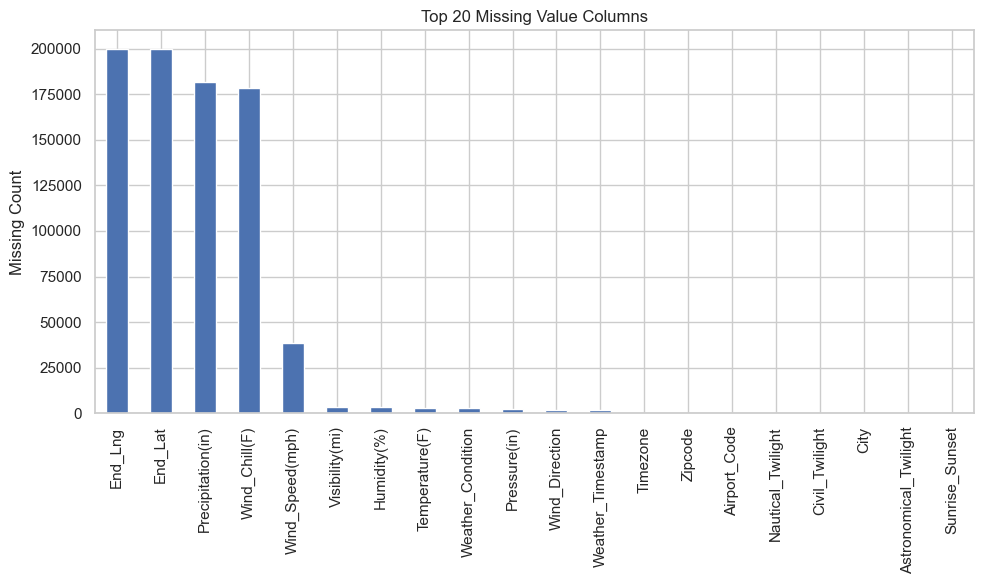

In [4]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

plt.figure(figsize=(10,6))

missing.head(20).plot(kind="bar")

plt.title("Top 20 Missing Value Columns")
plt.ylabel("Missing Count")

plt.tight_layout()

plt.show()

In [5]:
print("Duplicates :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

df['Start_Time'] = pd.to_datetime(df['Start_Time'])

df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month_name()
df['Day'] = df['Start_Time'].dt.day_name()
df['Hour'] = df['Start_Time'].dt.hour

print(df.shape)

Duplicates : 0
(200000, 50)


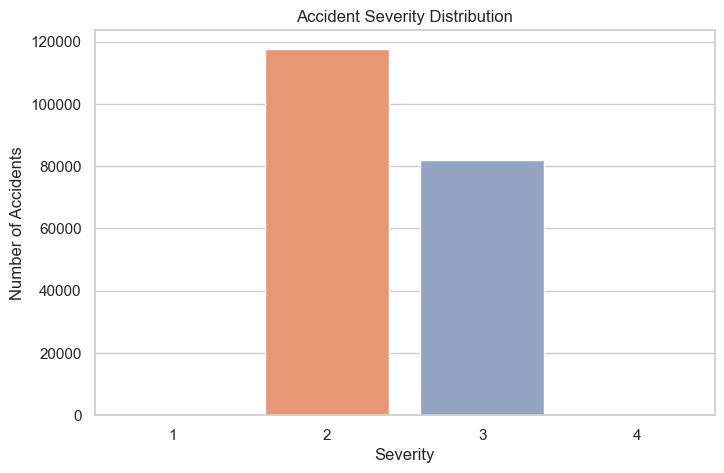

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Severity',
    palette='Set2'
)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")

plt.show()

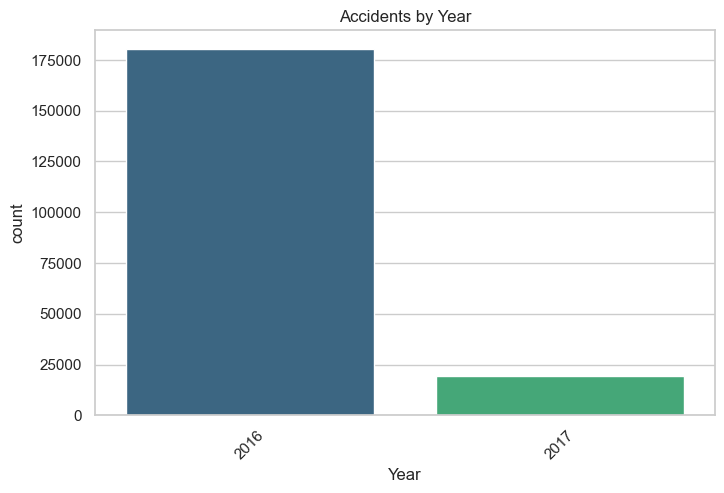

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Year',
    palette='viridis'
)

plt.title("Accidents by Year")
plt.xticks(rotation=45)

plt.show()

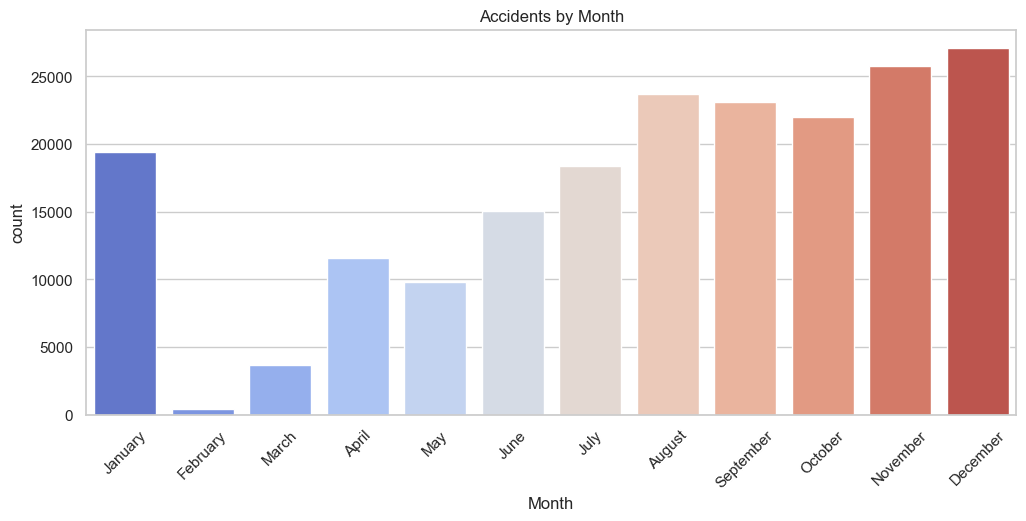

In [8]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='Month',
    order=month_order,
    palette='coolwarm'
)

plt.xticks(rotation=45)

plt.title("Accidents by Month")

plt.show()

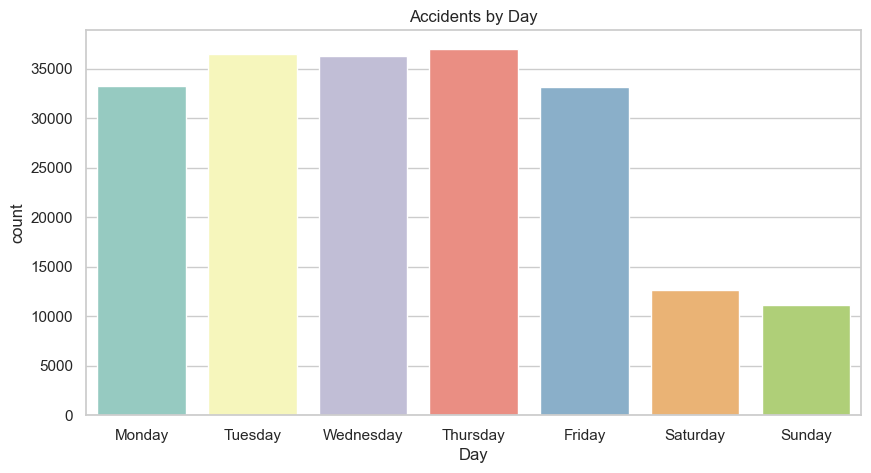

In [9]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Day',
    order=day_order,
    palette='Set3'
)

plt.title("Accidents by Day")

plt.show()

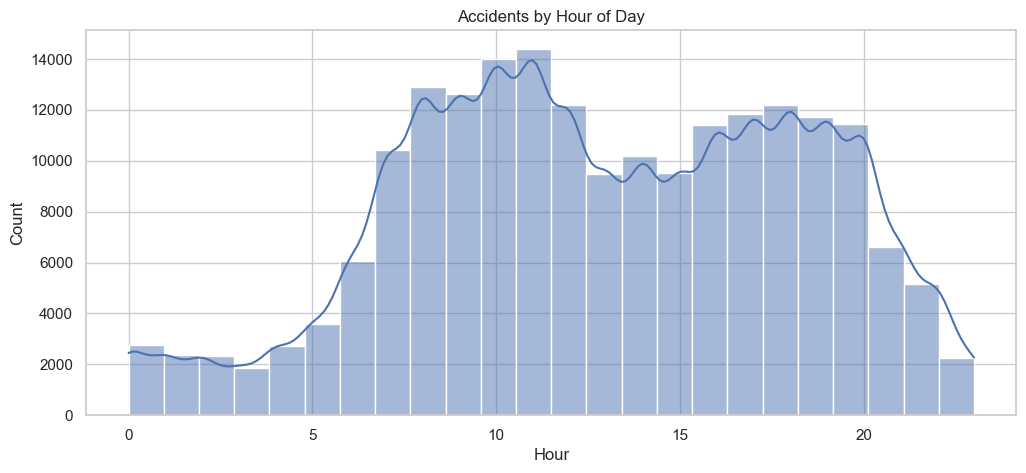

In [10]:
plt.figure(figsize=(12,5))

sns.histplot(
    df['Hour'],
    bins=24,
    kde=True
)

plt.title("Accidents by Hour of Day")

plt.xlabel("Hour")

plt.show()

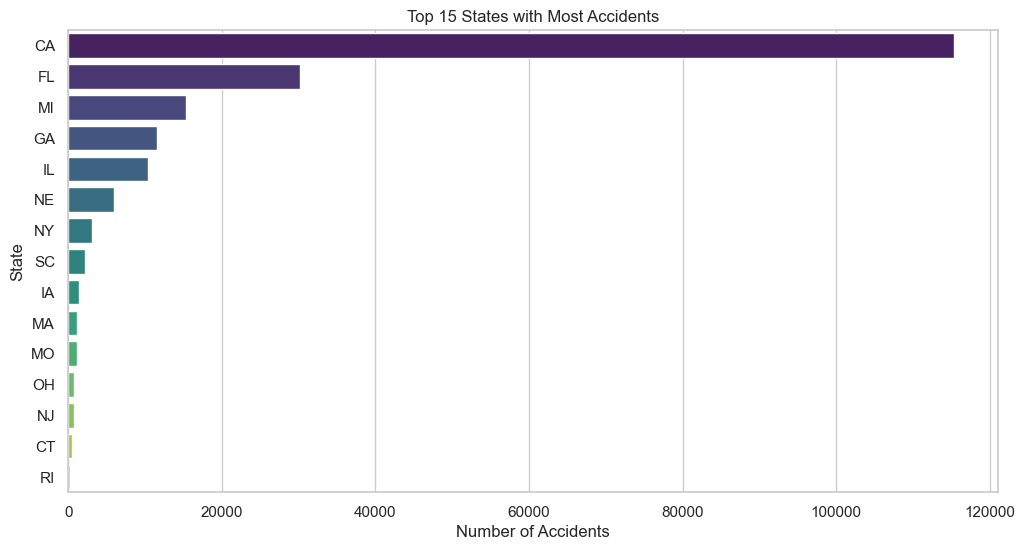

In [11]:
top_states = df['State'].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    palette='viridis'
)

plt.title("Top 15 States with Most Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("State")

plt.show()

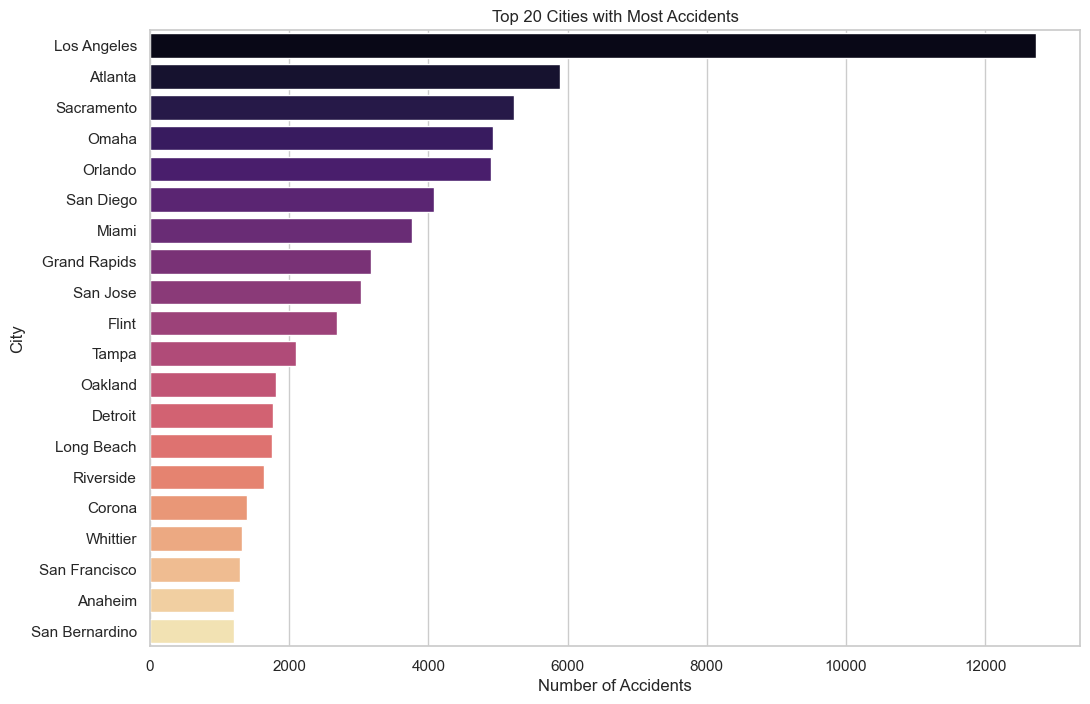

In [12]:
top_cities = df['City'].value_counts().head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index,
    palette='magma'
)

plt.title("Top 20 Cities with Most Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("City")

plt.show()

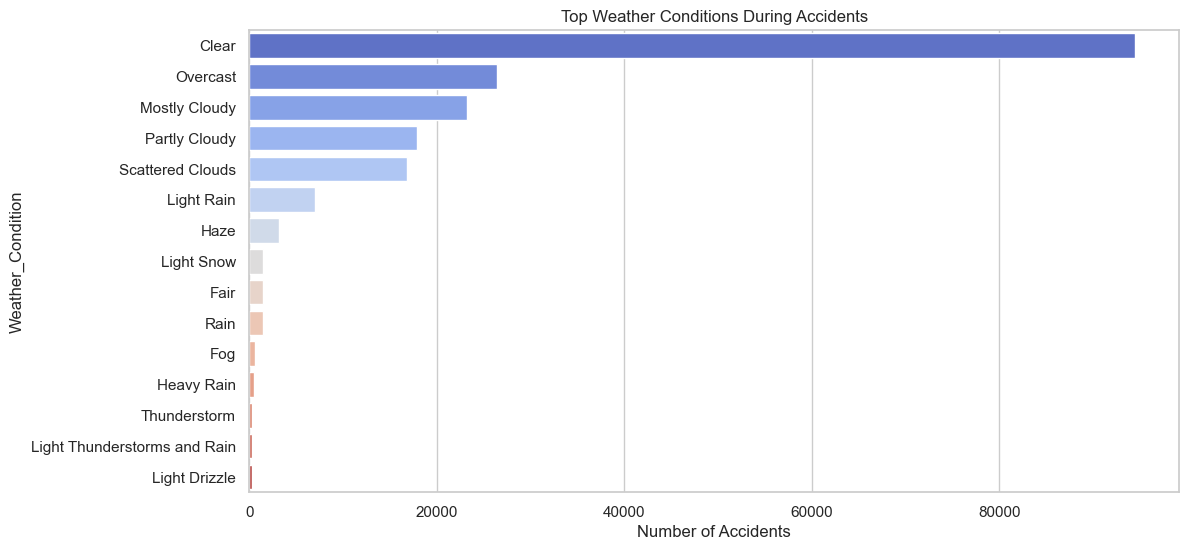

In [13]:
top_weather = df['Weather_Condition'].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_weather.values,
    y=top_weather.index,
    palette='coolwarm'
)

plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Number of Accidents")

plt.show()

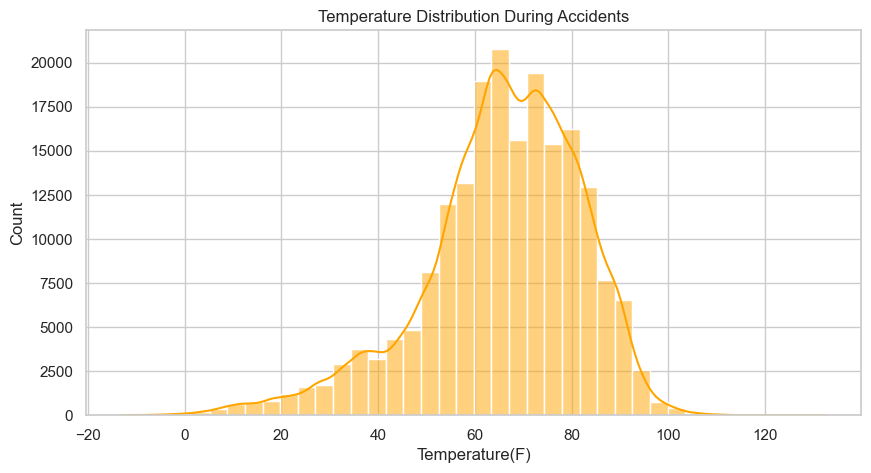

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Temperature(F)'],
    bins=40,
    kde=True,
    color='orange'
)

plt.title("Temperature Distribution During Accidents")

plt.show()

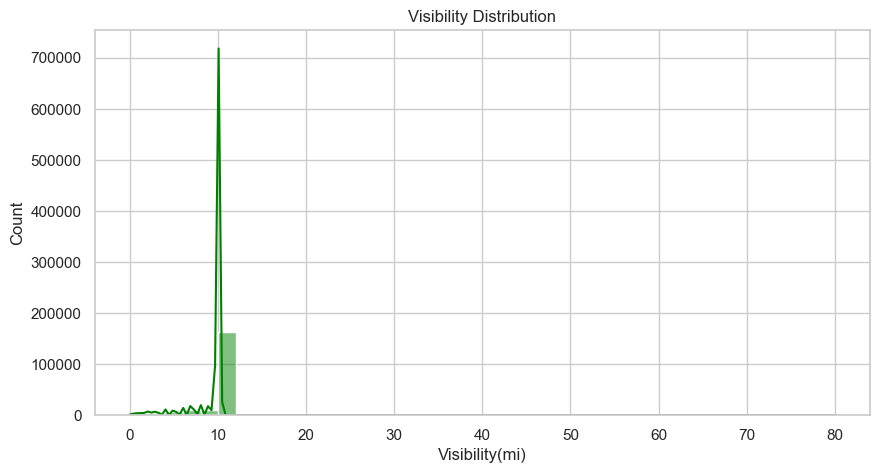

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Visibility(mi)'],
    bins=40,
    kde=True,
    color='green'
)

plt.title("Visibility Distribution")

plt.show()

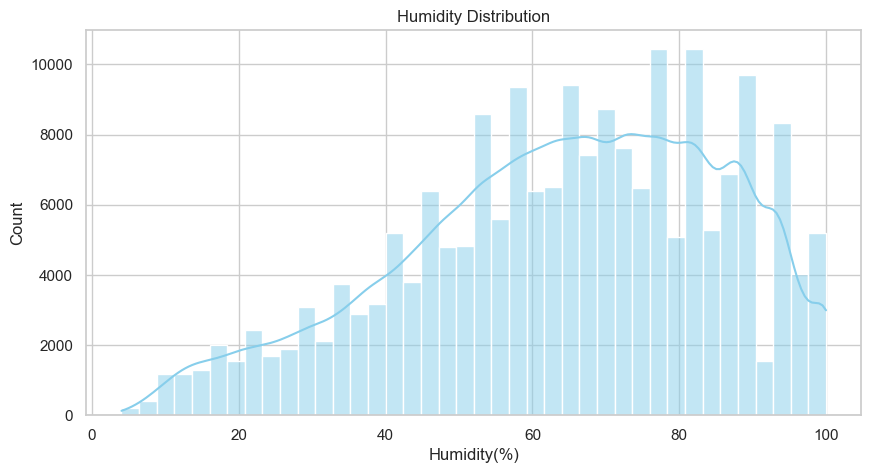

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Humidity(%)'],
    bins=40,
    kde=True,
    color='skyblue'
)

plt.title("Humidity Distribution")

plt.show()

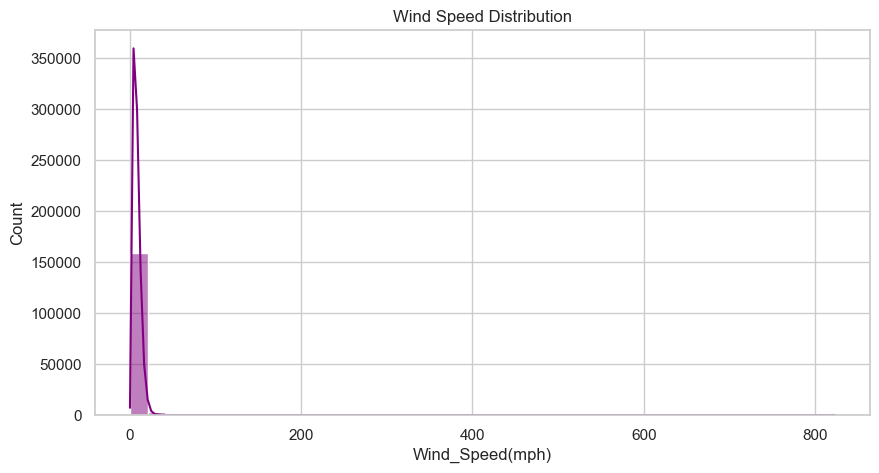

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Wind_Speed(mph)'],
    bins=40,
    kde=True,
    color='purple'
)

plt.title("Wind Speed Distribution")

plt.show()

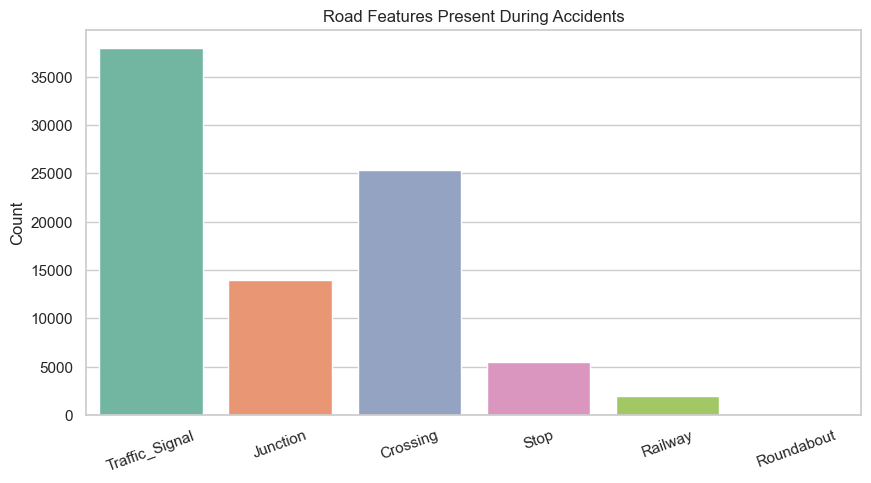

In [18]:
road_features = [
    'Traffic_Signal',
    'Junction',
    'Crossing',
    'Stop',
    'Railway',
    'Roundabout'
]

counts = []

for feature in road_features:
    counts.append(df[feature].sum())

plt.figure(figsize=(10,5))

sns.barplot(
    x=road_features,
    y=counts,
    palette='Set2'
)

plt.title("Road Features Present During Accidents")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

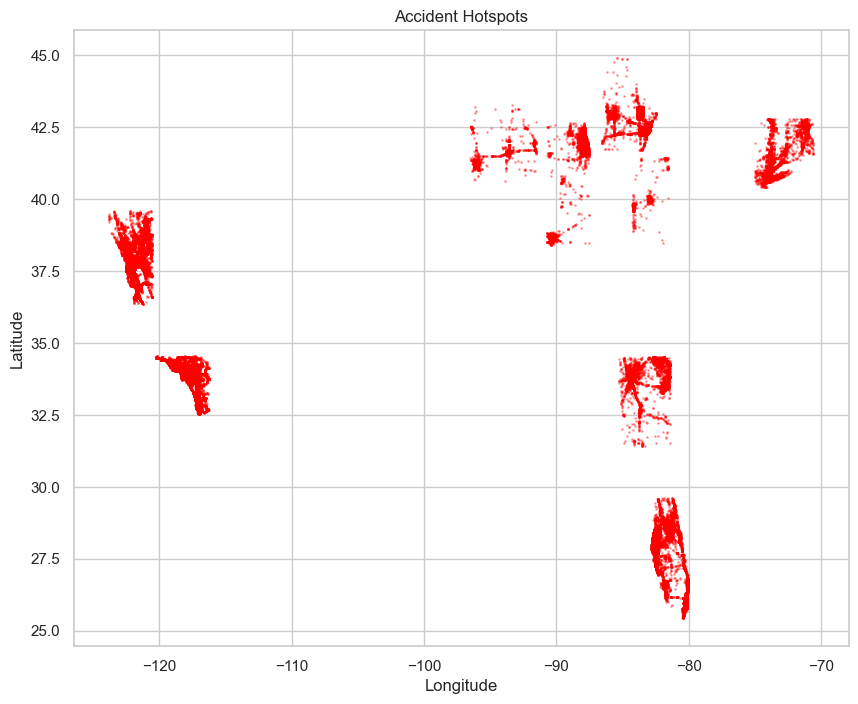

In [19]:
plt.figure(figsize=(10,8))

plt.scatter(
    df['Start_Lng'],
    df['Start_Lat'],
    s=1,
    alpha=0.3,
    color='red'
)

plt.title("Accident Hotspots")

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.show()

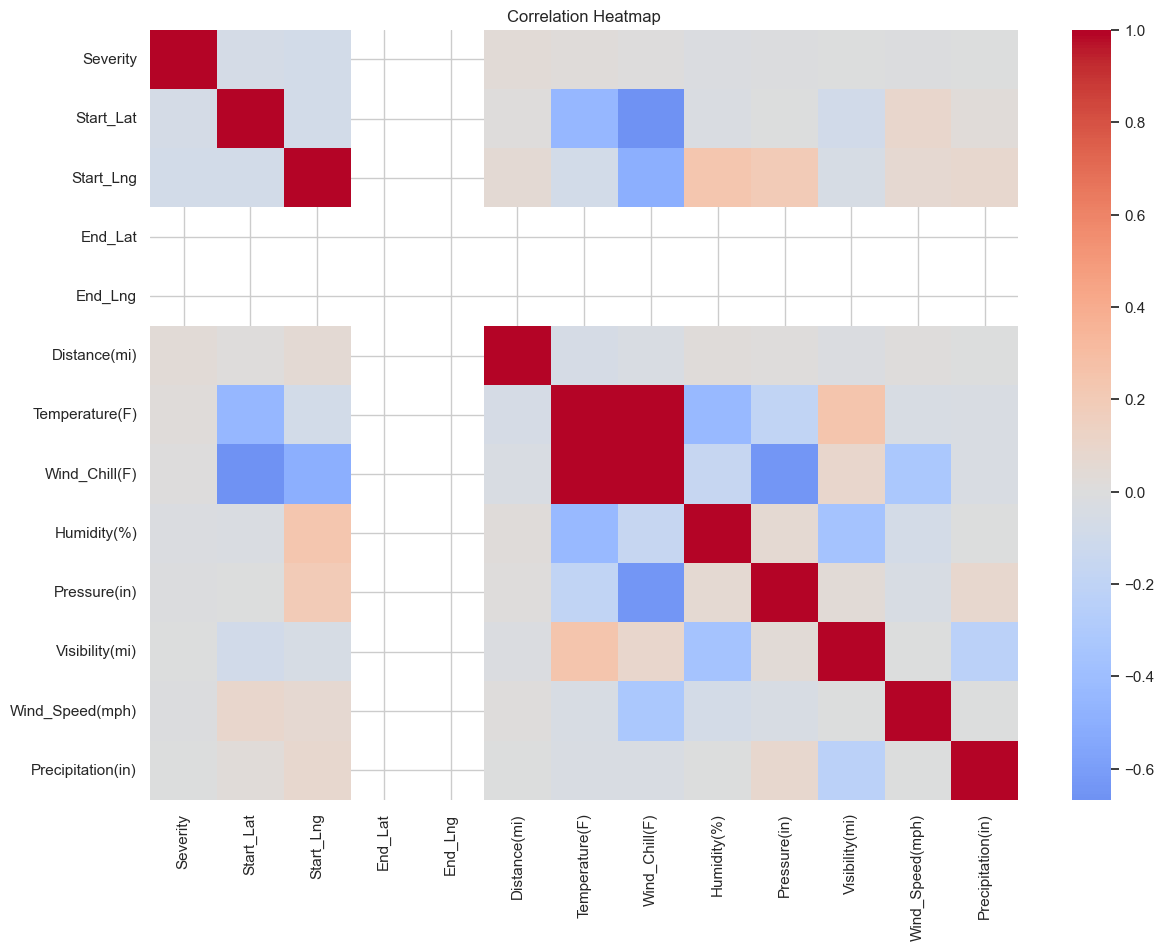

In [20]:
numeric = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric.corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

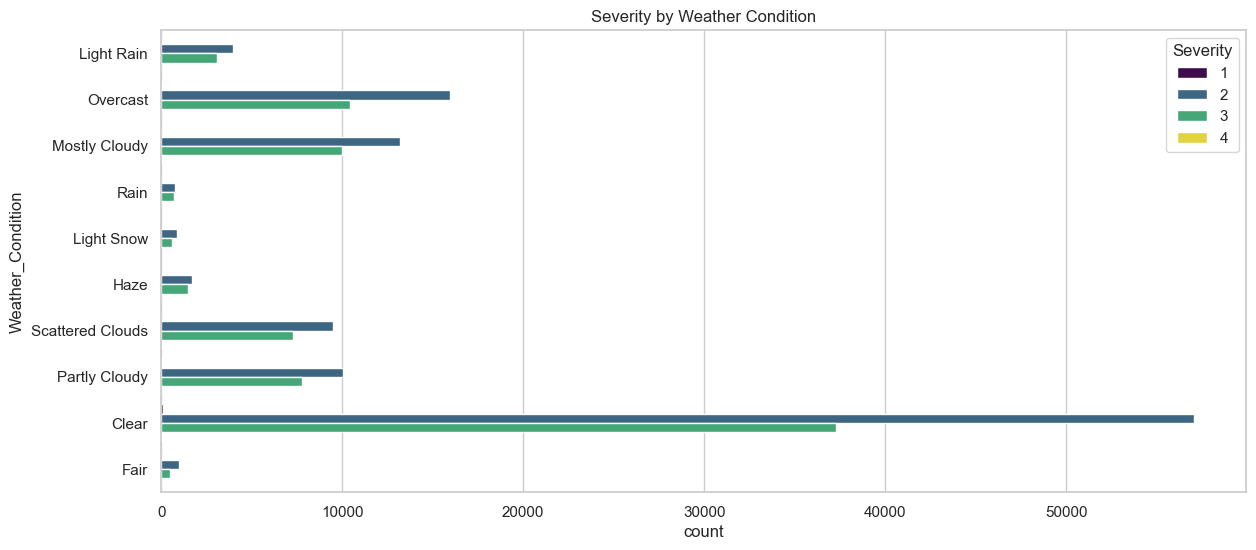

In [21]:
top_weather = df['Weather_Condition'].value_counts().head(10).index

filtered = df[df['Weather_Condition'].isin(top_weather)]

plt.figure(figsize=(14,6))

sns.countplot(
    data=filtered,
    y='Weather_Condition',
    hue='Severity',
    palette='viridis'
)

plt.title("Severity by Weather Condition")

plt.show()

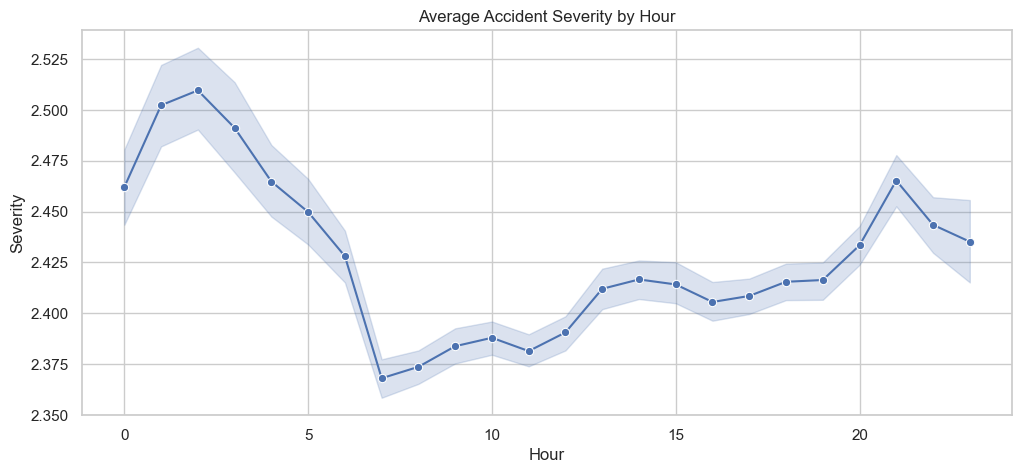

In [22]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x='Hour',
    y='Severity',
    estimator='mean',
    marker='o'
)

plt.title("Average Accident Severity by Hour")

plt.show()

In [23]:
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print(f"\nTotal Records Analysed : {len(df):,}")

print(f"\nMost Accident State : {df['State'].mode()[0]}")

print(f"Most Accident City : {df['City'].mode()[0]}")

print(f"Most Common Weather : {df['Weather_Condition'].mode()[0]}")

print(f"Peak Accident Hour : {df['Hour'].mode()[0]}:00")

print(f"Average Severity : {df['Severity'].mean():.2f}")

BUSINESS INSIGHTS

Total Records Analysed : 200,000

Most Accident State : CA
Most Accident City : Los Angeles
Most Common Weather : Clear
Peak Accident Hour : 11:00
Average Severity : 2.41


In [24]:
print("""
==================== FINAL CONCLUSIONS ====================

1. Accident frequency varies significantly by state and city.

2. Weather conditions such as rain, fog, and cloudy weather
   contribute to many accidents.

3. Peak traffic hours experience the highest number of accidents.

4. Road infrastructure such as traffic signals, crossings,
   and junctions are common accident locations.

5. Visibility and weather conditions have a noticeable
   impact on accident occurrence.

6. This analysis can help authorities identify accident
   hotspots and improve road safety.

===========================================================
""")


==================== FINAL CONCLUSIONS ====================

1. Accident frequency varies significantly by state and city.

2. Weather conditions such as rain, fog, and cloudy weather
   contribute to many accidents.

3. Peak traffic hours experience the highest number of accidents.

4. Road infrastructure such as traffic signals, crossings,
   and junctions are common accident locations.

5. Visibility and weather conditions have a noticeable
   impact on accident occurrence.

6. This analysis can help authorities identify accident
   hotspots and improve road safety.


